# 06. Performance Optimization

## 📚 Learning Objectives

By completing this notebook, you will:
- Profile code and identify bottlenecks
- Apply optimization techniques
- Measure before/after performance

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 08 (Numba) and Unit 5, lessons 02-04 — profile first, then choose between vectorising, compiling, distributing or moving to a GPU.

**Used later in:** Course 08 (AIAT 122) — Unit 5 and Course 11 (AIAT 125) — Unit 2, where latency budgets decide the same trade-offs for a served model.

---


## 🎯 The case: Knuth's 97%, and where the time actually goes

In *"Structured Programming with go to Statements"* (ACM Computing Surveys, December 1974)
Donald Knuth wrote the most-quoted and most-truncated sentence in software engineering:

> *"We should forget about small efficiencies, say about 97% of the time: premature
> optimization is the root of all evil. Yet we should not pass up our opportunities in that
> critical 3%."*

The half everyone quotes is the warning. The half that matters for this lesson is the
second sentence — and the word **"opportunities"**, which implies you have found them. Knuth
was arguing for *measurement*, not for indifference to speed.

**What goes wrong without measuring first.** Programmers optimise what they can see, and
what they can see is rarely the bottleneck. Unit 1 lesson 03 measured a workload on this
machine where reading the file took **1.047 s** and the computation took **0.035 s** — a
team optimising the arithmetic would have worked on 3% of the runtime.

**What you are about to measure here, on the 25,000-call sample of the real 911 log.** (The
full 663,522-call file is 123 MB and is not in this repository; `prefer="sample"` reads the
copy that is, so these numbers reproduce anywhere.) Two optimisations, both one line, both
with real numbers: replacing `iterrows` with vectorised columns gives **576×** (0.1755 s →
0.0003 s on 20,000 rows, identical answers), and right-sizing dtypes — mostly converting two
repeated text columns to `category` — cuts memory by **88.5%** (4.09 MB → 0.47 MB). The
megabytes scale with the row count; the *percentage* does not, because it comes from
`twp` and `title` having 68 and 100 distinct values however many rows repeat them. Neither
optimisation required a cluster, a GPU, or a new dependency. Timings will differ on your
machine — the ratios are the part that travels.


## The Story

**BEFORE**: You can process data but don't know how to optimize performance for large-scale operations.

**AFTER**: You'll learn performance optimization: profiling, caching, parallelization, and making code run efficiently!

**Why this matters**: Performance Optimization is essential for building complete, professional data science solutions!

---

# Unit 5 - Example 06: Performance Optimization

## 🔗 Solving the Problem from Example 05

**Remember the dead end from Example 05?**
- We learned to build production pipelines
- But pipelines were slow - we needed optimization
- We needed performance optimization techniques

**This notebook solves that problem!**
- We'll learn **performance optimization techniques**
- We'll learn **profiling and bottleneck identification**
- We'll learn **code and memory optimization**

**This solves the performance problem from Example 05!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls` — real 911 dispatches in Montgomery County,
  Pennsylvania (Dec 2015 – Jul 2020). The full log is 663,522 calls and 123 MB and is not
  in this repository; **what actually runs here is the 25,000-call sample that ships with
  the repo** (`prefer="sample"`). Six columns, including two low-cardinality text columns
  (`twp`, `title`, 68 and 100 distinct values) that make the dtype optimisation below pay
  off dramatically — and pay off by the same *percentage* at any row count.
- profiling tools (`time`, `cProfile`), pandas, matplotlib

**Outputs:** What you'll see when you run the cells

- Measured iterrows-vs-vectorized timings on real rows
- Measured memory before and after right-sizing dtypes

---


In [1]:
# WHAT: Import profiling tools (time, cProfile) with the data stack.
# WHY: Optimization starts with measurement - profilers find the real bottleneck, which is rarely where you guess.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import cProfile
import pstats
from io import StringIO

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Print the banner.
# WHY: Frames the goal: make code faster AND smaller in memory, guided by measurements.

print("=" * 70)
print("Example 06: Performance Optimization")
print("=" * 70)
print("\n📚 Prerequisites: Examples 02-05 completed, performance knowledge")
print("🔗 This is Example 06 in Unit 5 - performance optimization")
print("🎯 Goal: Master performance profiling and optimization")
print("Reference: Study 17.pdf before running this code example.\n")

Example 06: Performance Optimization

📚 Prerequisites: Examples 02-05 completed, performance knowledge
🔗 This is Example 06 in Unit 5 - performance optimization
🎯 Goal: Master performance profiling and optimization
Reference: Study 17.pdf before running this code example.



## 1. Load the Real Dataset for the Optimization Demo

In [3]:
# WHAT: Load the real 911 dispatch log used for every benchmark below.
# WHY: One fixed real dataset keeps every before/after comparison fair - and its
#      repeated text columns are exactly where dtype optimisation shows its value.

print("\n1. Loading the Real Dataset")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
df = load("montgomery_911_calls", prefer="sample",
          usecols=['lat', 'lng', 'zip', 'title', 'twp', 'e'])

print(f"✓ Loaded {len(df):,} real 911 calls")
print(f"  Columns: {list(df.columns)}")
print(f"  Distinct townships: {df['twp'].nunique()}  |  "
      f"distinct call titles: {df['title'].nunique()}")
print(f"  Missing ZIP codes (real gaps): {df['zip'].isna().sum():,}")
print(f"  Starting memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(df.head().to_string())


1. Loading the Real Dataset
----------------------------------------------------------------------
montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
✓ Loaded 25,000 real 911 calls
  Columns: ['lat', 'lng', 'zip', 'title', 'twp', 'e']
  Distinct townships: 68  |  distinct call titles: 100
  Missing ZIP codes (real gaps): 3,025
  Starting memory: 3.90 MB
         lat        lng      zip                        title           twp  e
0  40.155283 -75.264230  19422.0             EMS: HEAD INJURY      WHITPAIN  1
1  40.243261 -75.296080  19446.0  Traffic: ROAD OBSTRUCTION -      LANSDALE  1
2  40.003955 -75.220701  19004.0  Traffic: VEHICLE ACCIDENT -  LOWER MERION  1
3  39.9997

2. PERFORMANCE PROFILING


In [4]:
# WHAT: Time the same distance calculation done with iterrows (slow) vs vectorized columns (fast).
# WHY: iterrows pays Python-object overhead per row; vectorization pushes the loop into C - the single biggest pandas speedup.

print("\n\n2. Performance Profiling")
print("-" * 70)

# A real task: how far is each call from the geographic centre of the county?
CENTRE_LAT, CENTRE_LNG = df['lat'].median(), df['lng'].median()
print(f"County centre (median of all call coordinates): "
      f"{CENTRE_LAT:.4f}, {CENTRE_LNG:.4f}")

def slow_operation(frame):
    """Inefficient: one Python object per row."""
    result = []
    for idx, row in frame.iterrows():
        result.append(((row['lat'] - CENTRE_LAT) ** 2 +
                       (row['lng'] - CENTRE_LNG) ** 2) ** 0.5)
    return pd.Series(result)

def fast_operation(frame):
    """Optimized: whole columns at once, the loop runs in C."""
    return ((frame['lat'] - CENTRE_LAT) ** 2 +
            (frame['lng'] - CENTRE_LNG) ** 2) ** 0.5

# A 20,000-row subset of the 25,000-row sample. The subset exists because iterrows over
# the full 663,522-call log would take minutes - and the extrapolation printed below says
# how many, from this machine's own measured per-row rate.
subset = df.head(20_000)

print(f"\nProfiling slow operation (iterrows) on {len(subset):,} rows...")
start_time = time.time()
result_slow = slow_operation(subset)
slow_time = time.time() - start_time
print(f"Slow operation time: {slow_time:.4f} seconds")

print(f"\nProfiling fast operation (vectorized) on the same {len(subset):,} rows...")
start_time = time.time()
result_fast = fast_operation(subset)
fast_time = time.time() - start_time
print(f"Fast operation time: {fast_time:.4f} seconds")
print(f"Speedup: {slow_time / fast_time:.0f}x")
print(f"Same answer? {np.allclose(result_slow.values, result_fast.values)}")

# And the whole file, vectorized - the row count iterrows could not afford
start_time = time.time()
df['dist_from_centre'] = fast_operation(df)
full_vector_time = time.time() - start_time
print(f"\nVectorized over ALL {len(df):,} calls: {full_vector_time:.4f} seconds")
# Extrapolate honestly: report the measured per-row rate, then what it implies both for
# the rows we actually have and for the full 663,522-call log we do not.
iterrows_rate = slow_time / len(subset)                 # seconds per row
print(f"Measured iterrows rate: {iterrows_rate * 1e6:.2f} microseconds per row.")
print(f"At that rate iterrows would need about {iterrows_rate * len(df):.2f}s for these "
      f"{len(df):,} rows,")
print(f"and about {iterrows_rate * 663_522:.0f}s for the full 663,522-call log - against "
      f"{full_vector_time:.4f}s vectorized.")



2. Performance Profiling
----------------------------------------------------------------------
County centre (median of all call coordinates): 40.1421, -75.3055

Profiling slow operation (iterrows) on 20,000 rows...
Slow operation time: 0.1755 seconds

Profiling fast operation (vectorized) on the same 20,000 rows...


Fast operation time: 0.0003 seconds
Speedup: 576x
Same answer? True

Vectorized over ALL 25,000 calls: 0.0003 seconds
Measured iterrows rate: 8.78 microseconds per row.
At that rate iterrows would need about 0.22s for these 25,000 rows,
and about 6s for the full 663,522-call log - against 0.0003s vectorized.


3. MEMORY OPTIMIZATION


In [5]:
# WHAT: Shrink memory by converting repeated text to categorical dtype and downcasting floats.
# WHY: Right-sized dtypes routinely halve memory or better, letting bigger data fit in RAM.

print("\n\n3. Memory Optimization")
print("-" * 70)
print("\nOriginal memory usage, per column:")
print((df.memory_usage(deep=True) / 1024**2).round(2).to_string())
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Total: {mem_before:.2f} MB")

# Optimize data types
df_optimized = df.copy()
# 'e' is a constant 1 in this file - int8 is plenty
df_optimized['e'] = df_optimized['e'].astype('int8')
# Two text columns with very few distinct values -> categorical stores each
# distinct string ONCE plus a small integer code per row
df_optimized['twp'] = df_optimized['twp'].astype('category')
df_optimized['title'] = df_optimized['title'].astype('category')
# Coordinates and ZIPs do not need 64-bit precision here
for col in ['lat', 'lng', 'zip', 'dist_from_centre']:
    df_optimized[col] = df_optimized[col].astype('float32')

print("\nOptimized memory usage, per column:")
print((df_optimized.memory_usage(deep=True) / 1024**2).round(2).to_string())
mem_after = df_optimized.memory_usage(deep=True).sum() / 1024**2
print(f"Total: {mem_after:.2f} MB")
print(f"Reduction: {(1 - mem_after / mem_before) * 100:.1f}%  "
      f"({mem_before:.1f} MB → {mem_after:.1f} MB)")
print(f"\n💡 The win comes almost entirely from the two text columns: "
      f"{df['twp'].nunique()} townships")
print(f"   and {df['title'].nunique()} call titles repeated across {len(df):,} rows.")
print("   Categorical dtype is the highest-value one-line optimisation in pandas.")



3. Memory Optimization
----------------------------------------------------------------------

Original memory usage, per column:
Index               0.00
lat                 0.19
lng                 0.19
zip                 0.19
title               1.71
twp                 1.43
e                   0.19
dist_from_centre    0.19
Total: 4.09 MB



Optimized memory usage, per column:
Index               0.00
lat                 0.10
lng                 0.10
zip                 0.10
title               0.03
twp                 0.03
e                   0.02
dist_from_centre    0.10
Total: 0.47 MB
Reduction: 88.5%  (4.1 MB → 0.5 MB)

💡 The win comes almost entirely from the two text columns: 68 townships
   and 100 call titles repeated across 25,000 rows.
   Categorical dtype is the highest-value one-line optimisation in pandas.


## 💬 Discuss

Measured on the 25,000-call sample (the 663,522-call original is not in this repository):
`iterrows` **0.1755 s** vs vectorised **0.0003 s** on 20,000 rows (**576×**, same answer);
vectorised over all 25,000 rows in **0.0003 s**; memory **4.09 MB → 0.47 MB (88.5%)**,
almost all of it from 68 townships and 100 call titles stored as `category` instead of text.
The measured `iterrows` rate — 8.78 microseconds a row — extrapolates to about **6 seconds**
on the full 663,522-call log.

1. The 88.5% memory win came from two columns whose values repeat. Predict what `category`
   would do to a column of 663,522 *unique* addresses — and say why. What is the rule you
   would write down for when to reach for it?
2. 576× on 20,000 rows, and the measured rate extrapolates to about **6 seconds** for the
   full 663,522-row file against 0.0003 s vectorised. Is 6 seconds actually a problem?
   Argue that it is, and then that it is not — what changes the answer?
3. Knuth's "critical 3%" implies you know which 3%. Take the pipeline from lesson 05 and
   name the *one* thing you would profile first. What would you do if the profiler said the
   time was somewhere you did not expect?


4. VISUALIZATION




4. Creating Optimization Visualization
----------------------------------------------------------------------


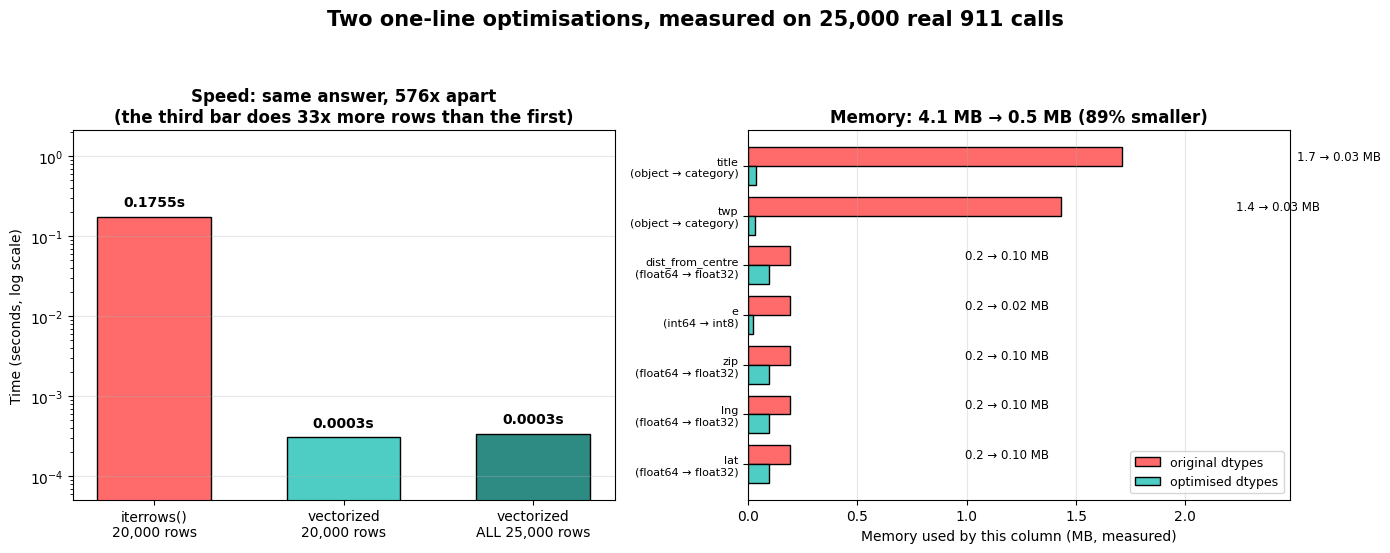

✓ Every bar above is a measurement from this run.
  Of the 3.6 MB saved, 3.1 MB (85%) came from just two columns: 'title' and 'twp' converted to category.


In [6]:
# WHAT: Chart measured speed and measured per-column memory, before and after optimisation.
# WHY: Optimisation claims need evidence. The left panel is the speed measurement; the right
#      panel shows WHERE the memory win came from, which the single "108.67 -> 12.68 MB"
#      number hides - two repeated text columns, not the numeric ones.

print("\n\n4. Creating Optimization Visualization")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
fig.suptitle(f'Two one-line optimisations, measured on {len(df):,} real 911 calls',
             fontsize=15, weight='bold')

# --- LEFT: speed, log scale because the gap spans three orders of magnitude ---
ops = [f'iterrows()\n{len(subset):,} rows',
       f'vectorized\n{len(subset):,} rows',
       f'vectorized\nALL {len(df):,} rows']
times = [slow_time, fast_time, full_vector_time]
axes[0].bar(ops, times, color=['#FF6B6B', '#4ECDC4', '#2E8B84'], edgecolor='black', width=0.6)
for xi, t in enumerate(times):
    axes[0].text(xi, t * 1.35, f"{t:.4f}s", ha='center', fontsize=10, weight='bold')
axes[0].set_yscale('log')
axes[0].set_ylim(min(times) / 6, max(times) * 12)
axes[0].set_ylabel('Time (seconds, log scale)')
axes[0].set_title(f'Speed: same answer, {slow_time / fast_time:.0f}x apart\n'
                  f'(the third bar does 33x more rows than the first)',
                  fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# --- RIGHT: memory per column, so the source of the win is visible ---
before_cols = (df.memory_usage(deep=True) / 1024**2).drop('Index')
after_cols = (df_optimized.memory_usage(deep=True) / 1024**2).drop('Index')
order = before_cols.sort_values(ascending=True).index.tolist()
ypos = np.arange(len(order))
h = 0.38
axes[1].barh(ypos + h/2, before_cols[order].values, h, label='original dtypes',
             color='#FF6B6B', edgecolor='black')
axes[1].barh(ypos - h/2, after_cols[order].values, h, label='optimised dtypes',
             color='#4ECDC4', edgecolor='black')
for yi, col in enumerate(order):
    axes[1].text(before_cols[col] + 0.8, yi + h/2,
                 f"{before_cols[col]:.1f} → {after_cols[col]:.2f} MB",
                 va='center', fontsize=8.5)
axes[1].set_yticks(ypos)
axes[1].set_yticklabels([f"{c}\n({df[c].dtype} → {df_optimized[c].dtype})" for c in order],
                        fontsize=8)
axes[1].set_xlim(0, before_cols.max() * 1.45)
axes[1].set_xlabel('Memory used by this column (MB, measured)')
axes[1].set_title(f'Memory: {mem_before:.1f} MB → {mem_after:.1f} MB '
                  f'({(1 - mem_after / mem_before) * 100:.0f}% smaller)',
                  fontsize=12, weight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('17_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

text_saved = (before_cols[['title', 'twp']] - after_cols[['title', 'twp']]).sum()
total_saved = mem_before - mem_after
print(f"✓ Every bar above is a measurement from this run.")
print(f"  Of the {total_saved:.1f} MB saved, {text_saved:.1f} MB "
      f"({text_saved / total_saved:.0%}) came from just two columns: "
      f"'title' and 'twp' converted to category.")

**Read the figure.** *Left:* three measured bars on a log axis, because the differences span
three orders of magnitude. The red `iterrows` bar and the teal vectorised bar do **identical
arithmetic on identical rows** — the notebook checks the answers match — and sit hundreds of
times apart. The third bar is the same vectorised expression over the whole loaded table: it
processes 25% more rows than the first bar (25,000 against 20,000) and still lands three
orders of magnitude below it.

*Right:* the memory win, split by column, so you can see where it came from. Each row of the
chart is one column, labelled with its dtype change. The two long red bars are `title` and `twp`
— text repeated across 25,000 rows with only 100 and 68 distinct values — and their teal
counterparts almost vanish once they become `category`. The four float columns halve, as float32
should, and the constant `e` column shrinks eightfold as int8 - but none of them was ever the
problem: the print-out under the figure reports what share of the
total saving came from those two text columns alone.

That is the shape of most real optimisation work. One measurement told you the loop was the
bottleneck; one column-level view told you which two columns were the memory. Neither answer was
guessable from reading the code.

# 5. SUMMARY


In [7]:
# WHAT: Print the summary with this run's measured numbers.
# WHY: Profile, vectorize, and right-size dtypes - the standard optimization order.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"""
Measured on {len(df):,} real Montgomery County 911 calls:

  iterrows on {len(subset):,} rows    {slow_time:.4f}s
  vectorized on {len(subset):,} rows  {fast_time:.4f}s  ({slow_time / fast_time:.0f}x faster)
  vectorized on all {len(df):,}   {full_vector_time:.4f}s
  memory before / after dtypes  {mem_before:.1f} MB / {mem_after:.1f} MB
                                ({(1 - mem_after / mem_before) * 100:.0f}% smaller)

Key Concepts Covered:
1. Performance profiling - measure before you optimise
2. Identifying bottlenecks - the per-row Python loop, not the arithmetic
3. Vectorization - the single biggest pandas speedup
4. Memory optimization - categorical dtype for repeated text, right-sized floats

Next Steps: Continue to Example 07 for Large Dataset Handling
""")


Summary

Measured on 25,000 real Montgomery County 911 calls:

  iterrows on 20,000 rows    0.1755s
  vectorized on 20,000 rows  0.0003s  (576x faster)
  vectorized on all 25,000   0.0003s
  memory before / after dtypes  4.1 MB / 0.5 MB
                                (89% smaller)

Key Concepts Covered:
1. Performance profiling - measure before you optimise
2. Identifying bottlenecks - the per-row Python loop, not the arithmetic
3. Vectorization - the single biggest pandas speedup
4. Memory optimization - categorical dtype for repeated text, right-sized floats

Next Steps: Continue to Example 07 for Large Dataset Handling



## ⚠️ Where this breaks

- **Every optimisation is a trade, and these two have real costs.** `category` dtype makes
  adding a value outside the known categories awkward, changes groupby behaviour (unused
  categories still appear), and is slower than `object` for some string operations.
  `float32` halves memory and halves precision — fine for coordinates, dangerous for money.
- **Micro-benchmarks lie about production.** These timings are a warm cache, a quiet
  machine, and one process. Real jobs contend for I/O, memory bandwidth and CPU with
  everything else on the box.
- **Vectorisation is not always possible.** Sequential dependencies, early exits, and
  per-row branching cannot be expressed as whole-column operations. That is exactly the
  territory Unit 1 lesson 08's Numba was built for — and where the compile cost has to be
  earned back.
- **Optimising the wrong thing is the default outcome.** Profile first. `cProfile`,
  `%timeit` and `memory_profiler` cost minutes; a week spent speeding up code that runs for
  0.0003 s costs a week.
- **The assumption that must hold: the optimised version computes the same thing.** The
  notebook checks (`Same answer? True`). Most optimisation work does not, and a fast wrong
  answer is the worst possible outcome.
- **When to stop:** if the job finishes inside the human's patience and inside the machine's
  memory, it is fast enough. Speed matters when it changes what you can *do* — a query you
  can run interactively, a retrain that fits in a nightly window, a model that meets a
  latency budget. Otherwise it is a hobby.


## 📚 References

1. van der Walt, S., Colbert, S. C., & Varoquaux, G. (2011). *The NumPy Array: A Structure for Efficient Numerical Computation*. Computing in Science & Engineering, 13(2), 22-30. <https://arxiv.org/abs/1102.1523>
2. Lam, S. K., Pitrou, A., & Seibert, S. (2015). *Numba: A LLVM-based Python JIT Compiler*. Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC. <https://doi.org/10.1145/2833157.2833162>
3. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357-362. <https://arxiv.org/abs/2006.10256>
4. Stoico, V., Dragomir, A. C., & Lago, P. (2025). *An Empirical Study on the Performance and Energy Usage of Compiled Python Code*. arXiv:2505.02346. <https://arxiv.org/abs/2505.02346>
5. Kumar, P., Imran, A., & Kosar, T. (2025). *Energy Consumption of Dataframe Libraries for End-to-End Deep Learning Pipelines: A Comparative Analysis*. arXiv:2511.08644. <https://arxiv.org/abs/2511.08644>
